## **PARTE 1**

**Importamos las librerías necesarias**

In [3]:
import pandas as pd
import numpy as np
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import os

**Carga de datos**

In [4]:
#Cargamos la bd
df = pd.read_excel("BD_creditos (2).xlsx")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   tipo_credito                   10763 non-null  int64         
 1   fecha_prestamo                 10763 non-null  datetime64[ns]
 2   capital_prestado               10763 non-null  float64       
 3   plazo_meses                    10763 non-null  int64         
 4   edad_cliente                   10763 non-null  int64         
 5   tipo_laboral                   10763 non-null  object        
 6   salario_cliente                10763 non-null  int64         
 7   total_otros_prestamos          10763 non-null  int64         
 8   cuota_pactada                  10763 non-null  int64         
 9   puntaje                        10763 non-null  float64       
 10  puntaje_datacredito            10757 non-null  float64       
 11  cant_creditosvi

**Dimensión del dataset**
Lo realizamos para visualizar inicialmente el número de registros que puede asemejarse con el tamaño del negocio y el número de varibales para poder comenzar a entender la complejidad del modelo

In [5]:
df.shape

(10763, 23)

## **PARTE 2**

In [6]:
#Para mostrar todas las filas y columnas del dataframe
pd.options.display.max_columns =  None
pd.options.display.max_rows = None

In [7]:
df.head(10)

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,4,2025-01-07 14:40:36,1852560.0,12,32,Empleado,3500000,1000000,128650,95.227787,795.0,0,2,0.0,0.0,NaN,NaN,0,0,0,916148.0,Creciente,1
1,4,2025-01-09 11:18:48,3181080.0,6,34,Empleado,5000000,2000000,441817,95.227787,796.0,0,7,0.0,0.0,NaN,NaN,0,0,0,4473774.0,Creciente,1
2,9,2024-12-26 18:52:57,670200.0,5,34,Independiente,5000000,2000000,108632,95.227787,727.0,5,0,0.0,274561.0,274561.0,NaN,2,0,1,NaN,NaN,1
3,9,2024-12-04 14:20:50,506806.8,2,25,Independiente,3000000,900000,199684,95.227787,864.0,8,1,0.0,27564.0,27564.0,NaN,1,0,6,NaN,NaN,1
4,4,2025-04-30 18:41:57,999780.0,10,26,Empleado,2000000,600000,92509,95.227787,771.0,0,3,0.0,0.0,NaN,NaN,0,0,0,61000.0,Creciente,1
5,9,2024-11-30 11:38:41,465460.8,2,29,Independiente,3000000,1000000,183393,86.830187,678.0,7,2,0.0,4158.0,4158.0,NaN,0,0,4,NaN,NaN,1
6,9,2024-12-04 11:26:23,1084186.8,8,28,Independiente,3000000,1000000,112736,86.830187,665.0,2,1,0.0,6182.0,6182.0,NaN,1,0,0,NaN,NaN,1
7,4,2025-03-27 14:57:24,556680.0,6,30,Independiente,2000000,700000,82757,18.451409,738.0,0,4,0.0,0.0,NaN,NaN,0,0,0,955038.0,Creciente,0
8,9,2025-02-05 17:31:26,4627576.8,10,33,Independiente,2000000,800000,392490,47.613894,769.0,0,2,0.0,0.0,NaN,NaN,0,0,0,NaN,NaN,0
9,4,2024-12-15 11:23:46,2100000.0,8,26,Empleado,1200000,300000,237864,28.340846,785.0,0,1,0.0,0.0,NaN,NaN,0,0,0,1193037.0,Estable,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   tipo_credito                   10763 non-null  int64         
 1   fecha_prestamo                 10763 non-null  datetime64[ns]
 2   capital_prestado               10763 non-null  float64       
 3   plazo_meses                    10763 non-null  int64         
 4   edad_cliente                   10763 non-null  int64         
 5   tipo_laboral                   10763 non-null  object        
 6   salario_cliente                10763 non-null  int64         
 7   total_otros_prestamos          10763 non-null  int64         
 8   cuota_pactada                  10763 non-null  int64         
 9   puntaje                        10763 non-null  float64       
 10  puntaje_datacredito            10757 non-null  float64       
 11  cant_creditosvi

In [9]:
#Revisión del tipo de dato
df.dtypes.value_counts()

,count
int64,12
float64,8
object,2
datetime64[ns],1


In [10]:
#Columnas del dataframe
df.columns

Index(['tipo_credito', 'fecha_prestamo', 'capital_prestado', 'plazo_meses',
       'edad_cliente', 'tipo_laboral', 'salario_cliente',
       'total_otros_prestamos', 'cuota_pactada', 'puntaje',
       'puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta',
       'saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor',
       'creditos_sectorFinanciero', 'creditos_sectorCooperativo',
       'creditos_sectorReal', 'promedio_ingresos_datacredito',
       'tendencia_ingresos', 'Pago_atiempo'],
      dtype='object')

In [11]:
#Caracterización inicial de las variables
# Variables numéricas
variables_numericas = df.select_dtypes(include=['int64','float64']).columns.tolist()

# Variables categóricas
variables_categoricas = df.select_dtypes(include=['object']).columns.tolist()

print("Variables Numéricas:", variables_numericas)
print("Variables Categóricas:", variables_categoricas)


Variables Numéricas: ['tipo_credito', 'capital_prestado', 'plazo_meses', 'edad_cliente', 'salario_cliente', 'total_otros_prestamos', 'cuota_pactada', 'puntaje', 'puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta', 'saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor', 'creditos_sectorFinanciero', 'creditos_sectorCooperativo', 'creditos_sectorReal', 'promedio_ingresos_datacredito', 'Pago_atiempo']
Variables Categóricas: ['tipo_laboral', 'tendencia_ingresos']


In [12]:
#Visualizamos los valores unicos de cada variable
for col in df.columns:
    print(f"\n Columna: {col}")
    print(df[col].unique())




 Columna: tipo_credito
[ 4  9 10  6  7 68]

 Columna: fecha_prestamo
<DatetimeArray>
['2025-01-07 14:40:36', '2025-01-09 11:18:48', '2024-12-26 18:52:57',
 '2024-12-04 14:20:50', '2025-04-30 18:41:57', '2024-11-30 11:38:41',
 '2024-12-04 11:26:23', '2025-03-27 14:57:24', '2025-02-05 17:31:26',
 '2024-12-15 11:23:46',
 ...
 '2024-12-04 16:39:13', '2024-12-14 10:21:08', '2025-03-31 11:27:28',
 '2024-12-05 09:35:51', '2025-01-16 16:28:48', '2024-12-18 09:32:36',
 '2025-01-16 10:57:01', '2025-04-19 14:41:28', '2024-12-06 15:15:07',
 '2024-12-13 16:55:44']
Length: 10758, dtype: datetime64[ns]

 Columna: capital_prestado
[1852560.  3181080.   670200.  ... 1784714.4 4880618.4  640880.4]

 Columna: plazo_meses
[12  6  5  2 10  8 18  3  9 36 11 30 24  4 20  7 90 48]

 Columna: edad_cliente
[ 32  34  25  26  29  28  30  33  21  22  20  27  24  36  35  31  23  37
  62  56  57  46  42  39  43  40  54  55  52  61  58  38  48  49  41  60
  59  53  66  47  63  69  68  64  65  67  44  50  51  45  19 

In [13]:
#Corrección de la columna tendencia_ingresos
# Valores válidos
valores_validos = ['Creciente', 'Estable', 'Decreciente']

# Reemplazar todo lo que NO esté en la lista por NaN
df['tendencia_ingresos'] = np.where(
    df['tendencia_ingresos'].isin(valores_validos),
    df['tendencia_ingresos'],
    np.nan
)


In [14]:
#Corrección de la columna tipo_producto
df['tipo_credito'] = df['tipo_credito'].astype('object')

In [15]:
# Variables numéricas
variables_numericas = df.select_dtypes(include=['int64','float64']).columns.tolist()

# Variables categóricas
variables_categoricas = df.select_dtypes(include=['object']).columns.tolist()

print("Variables Numéricas:", variables_numericas)
print("Variables Categóricas:", variables_categoricas)


Variables Numéricas: ['capital_prestado', 'plazo_meses', 'edad_cliente', 'salario_cliente', 'total_otros_prestamos', 'cuota_pactada', 'puntaje', 'puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta', 'saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor', 'creditos_sectorFinanciero', 'creditos_sectorCooperativo', 'creditos_sectorReal', 'promedio_ingresos_datacredito', 'Pago_atiempo']
Variables Categóricas: ['tipo_credito', 'tipo_laboral', 'tendencia_ingresos']


## **Clasificación Conceptual de las variables**

**Variables del crédito**

*   tipo_credicto:Esta variable es categórica nominal politomica, representa un tipo de producto financiero
*   capital_prestado:Esta variable es numérica continua y mide el monto desembolsado


*   plazo_meses:Esta variable es numérica discreta y mide el tiempo del crédito
*   cuota_pactada:Esta variable es numérica continua y
mide el pago mensual acordado

**Variables del cliente**

*   edad_cliente:Esta variable es númerica discreta
*   salario_cliente:Esta variable es númerica continua y mide la capacidad de pago  y el ingreso mensual declarado


*   tipo_laboral:Esta variable es categótica nominal politómica

**Variables de endeudamiento**


*   total_otros_prestamos:Esta variable es númerica continua y mide el endeudamiento externo
*   cant_creditosvigentes:Esta variable es númerica discreta y mide el número de créditos activos


*   saldo_total:Esta variable es númerica continua y mide el total de deuda vigente
*   saldo_principal:Esta varibale es númerica continua y mide el capital pendiente por pagar


*   saldo_mora:Esta varibale es númerica continua y mide la mora actual
*   saldo_mora_codeudor:Esta variable es númerica continua y mide la mora del respaldo

**Variables de Historial créditicio**

*   puntaje:Esta variable es númerica continua ordinal y mide el score interno del banco
*   puntaje_datacredito:Esta variable es númerica continua y mide el puntaje historico en el sistema financier


*   huella_consulta:Esta variable es númerica discreta y mide número de veces que las entidades financieras han buscado al cliente

**Variables de sectores de crédito**


*   credito_sectorFinanciero, credito_sectorCooperativo, credito_sectorReal:Estas variables son númericas discretas y miden la exposición por sector

**Variables de Ingresos Externos**
*   promedido_ingresos_datacredito:Esta variable es númerica continua y mide el ingreso historico validado


*   tendencia_ingresos:Esta variable es categorica ordinal politómica y indica el comportamiento reciente de los ingresos

**Variable Objetivo**


*   pago_atiempo:Esta variable es categorica nominal dicotomica y representa el target del modelo


























In [16]:
#Revisión de nulos
df.isnull().sum()

,0
tipo_credito,0
fecha_prestamo,0
capital_prestado,0
plazo_meses,0
edad_cliente,0
tipo_laboral,0
salario_cliente,0
total_otros_prestamos,0
cuota_pactada,0
puntaje,0


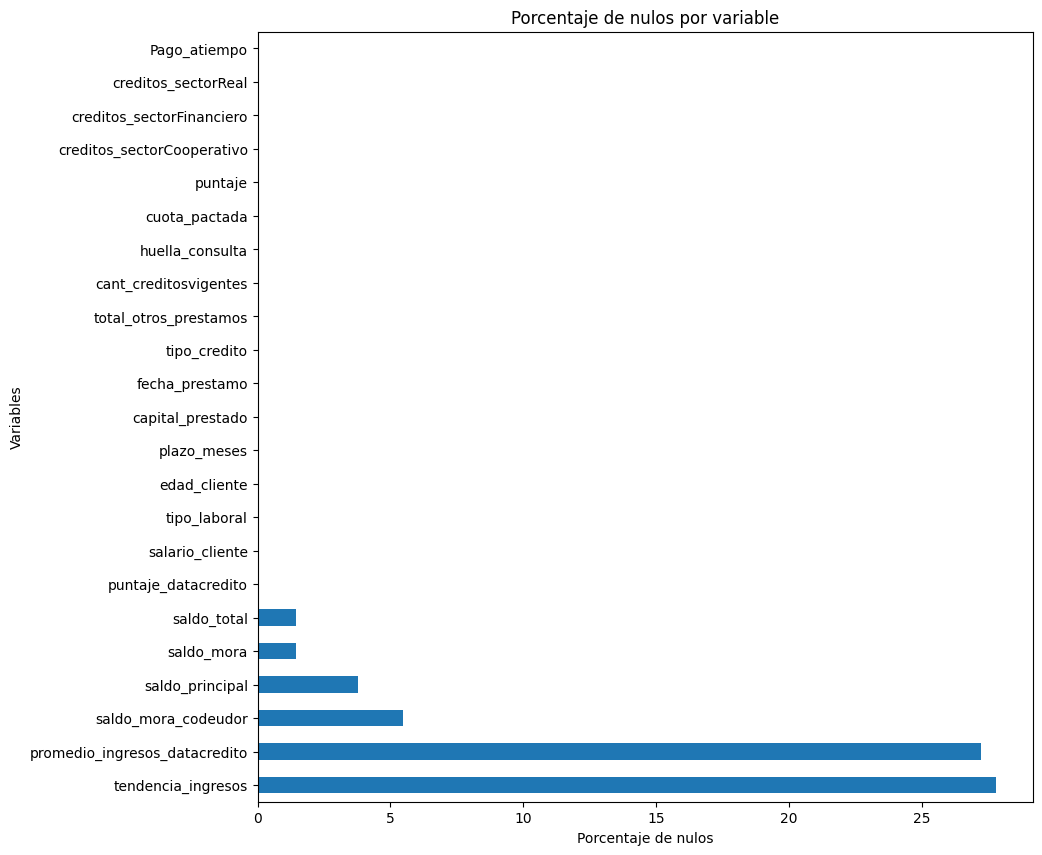

In [17]:
#Porcentaje de nulos por variable
(df.isnull().mean()*100).sort_values(ascending=False).plot(kind='barh', figsize=(10,10))
plt.title('Porcentaje de nulos por variable')
plt.xlabel('Porcentaje de nulos')
plt.ylabel('Variables')
plt.show()

**Gracias al data.info podemos observar que en las columnas de:**

*   puntaje_datacredito hay 6 valores faltantes, esta variable nos habla del score otorgado por la central de riesgo Datacrédito, si la variable no cuenta con valor puede significar que la persona no cuenta con historial crediticio, que la persona no esta reportada en Datacrédito o fue un error en la captura del dato.
*   saldo_mora hay 156 valores faltantes, esta variable nos muestra el monto actualmente en mora del cliente, osea lo que debe,si la variable no cuenta con valor puede significar que la persona no tiene deuda o es un error del sistema.

*   saldo_total hay 156 valores faltantes, esta variable nos muestra el total de deuda del cliente, si la varibale no cuenta con valor puede significar que la persona no tiene deudas activas, el crédito ya esta cerrado o que fue un error de captura o de carga del dato.
*   saldo_principal hay 405 valores faltantes, esta varibale nos muestra el monto actual adeudado osea el capital de la persona, si la variable no cuenta con valor puede significar un credito ya cancelado o un error en la base, un credito actuvi no debería estar nulo.

*   saldo_mora_codeudor hay 590 valores faltantes,esta varibale nos muestra el saldo en mora del codeudor, si la variable no cuenta con valor puede significar que la persona no cuenta con el codeudor, que tiene un codeudor sin mora o fue un error en la captura del dato.
*   promedio_ingresos_datacredito hay 2930 valores faltantes, esta variable nos muestra el promedio de ingresos reportados en las centrales de riesgo, si la variable no cuenta con valor puede significar que es un nuevo cliente, notiene historial financiero o no esta reportado en las centrales.

*   tendencias_ingresos hay 2990 valores faltantes, esta variable nos muestra el comportamiendo de los ingresos en el tiempo, si la variable no cuenta con valor puede significar que es un cliente nuevo o que no hay suficiente historial para calcular tendencia.

In [18]:
#Identificación del target
df['Pago_atiempo'].value_counts()

,count
Pago_atiempo,
1,10252
0,511


Se puede observar que la variable objetivo Pago_atiempo es una variable dicotomica binaria (1=pagó, 0=no pagó), la cual esta notoriamente desbalanceada, teniendo como clase mayoritaria a 1=pagó y clase minoritaria a 0=no pagó

## **Estadísticas Generales**

In [19]:
#Estadisticas descriptivas
df.describe(include='all').transpose()

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
tipo_credito,10763.0,6.0,4.0,7747.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fecha_prestamo,10763,NaN,NaN,NaN,2025-04-16 23:06:02.111121408,2024-11-26 09:17:04,2025-01-20 17:33:07.500000,2025-03-27 16:23:12,2025-06-16 13:27:58,2026-04-26 18:43:52,NaN
capital_prestado,10763.0,NaN,NaN,NaN,2434315.001319,360000.0,1224831.0,1921920.0,3084840.0,41444152.8,1909642.758997
plazo_meses,10763.0,NaN,NaN,NaN,10.575583,2.0,6.0,10.0,12.0,90.0,6.632082
edad_cliente,10763.0,NaN,NaN,NaN,43.94862,19.0,33.0,42.0,53.0,123.0,15.060877
tipo_laboral,10763,2,Empleado,6754,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salario_cliente,10763.0,NaN,NaN,NaN,17216431.459909,0.0,2000000.0,3000000.0,4875808.0,22000000000.0,355476717.60349
total_otros_prestamos,10763.0,NaN,NaN,NaN,6238869.648518,0.0,500000.0,1000000.0,2000000.0,6787675263.0,118418316.941069
cuota_pactada,10763.0,NaN,NaN,NaN,243617.406671,23944.0,121041.5,182863.0,287833.5,3816752.0,210493.694608
puntaje,10763.0,NaN,NaN,NaN,91.170036,-38.00999,95.227787,95.227787,95.227787,95.227787,16.465441


**Estadística Descriptiva**


*   capital_prestado: Existe una gran diferencia entre el Q3= 3'084.840 y el maximo=41'444.152
*   plazo_meses: Se puede observar que la mayoría de los créditos son a corto plazo de 6-12 meses


*   edad_cliente: En esta variable tenemos outliers ya que tenemos que la edad minima son 19 años y la edad maxima son 123 años
*   total_otros_prestamos:El maximo total de otros prestamos alcaza los 6.7 mil millones de pesos lo que podría indicar que hay clientes altamente sobreendeudados


*   puntaje: El valor maximo del puntaje 95.227 aparece repetido en los Q1, Q2 y Q3, indicando posiblemente que el 75% de los clientes tienen el mismo puntaje
*   puntaje_datacredito: En esta variable tenes outliers, ya que en el valor minimo de la variable tenemos -7.0 y en el valor maxito tenemos 999.0, teniendo en cuenta que los puntajes en datacrédito oscilan entre los 150-950 puntos


*   saldo_mora: Se observa que el valor en Q1, Q2 y Q3 son 0, lo que psoiblemente indica que más del 75% de los clientes no tienen mora
*   saldo_mora_codeudor: Se observa que el valor en Q1, Q2 y Q3 son 0, lo que probablemente indica que casi nadie tiene mora en codeudor


*   promedio_ingresos_datacredito: Se observa que 2930 de los clientes no cuenta con información externa, lo que representa el 27% del dataset, lo que probablemente puede indicar que se trata de un cliente nuevo, sin historial o no bancarizado











**Unificación de valores nulos**

In [20]:
#Revisar la representación de los nulos en las columnas que contienen valores nulos
columnas_con_nulos = [
    'puntaje_datacredito',
    'saldo_mora',
    'saldo_total',
    'saldo_principal',
    'saldo_mora_codeudor',
    'promedio_ingresos_datacredito',
    'tendencia_ingresos'
]

for col in columnas_con_nulos:
    print("\n" + "="*50)
    print(f"Columna: {col}")
    print("Tipo de dato:", df[col].dtype)
    print("\nValores únicos incluyendo nulos:")
    print(df[col].value_counts(dropna=False).head(15))



Columna: puntaje_datacredito
Tipo de dato: float64

Valores únicos incluyendo nulos:
puntaje_datacredito
0.0      145
783.0    102
802.0    102
791.0    100
801.0     98
804.0     98
769.0     95
796.0     93
814.0     92
792.0     91
793.0     91
786.0     90
815.0     89
772.0     87
795.0     87
Name: count, dtype: int64

Columna: saldo_mora
Tipo de dato: float64

Valores únicos incluyendo nulos:
saldo_mora
0.0        10552
NaN          156
30.0           2
172.0          1
67.0           1
63.0           1
4379.0         1
866.0          1
1584.0         1
1463.0         1
115.0          1
336.0          1
4973.0         1
10081.0        1
105.0          1
Name: count, dtype: int64

Columna: saldo_total
Tipo de dato: float64

Valores únicos incluyendo nulos:
saldo_total
0.0      789
NaN      156
39.0      10
35.0      10
29.0       9
53.0       7
49.0       7
55.0       6
70.0       6
61.0       6
37.0       6
67.0       5
44.0       5
175.0      5
168.0      5
Name: count, dtype:

In [21]:
#Visualización de los 6 valores nulos de la columna puntaje_datacredito
df['puntaje_datacredito'].value_counts(dropna=False)

,count
puntaje_datacredito,
0.0,145
783.0,102
802.0,102
791.0,100
801.0,98
804.0,98
769.0,95
796.0,93
814.0,92


Se revisó la representación de valores faltantes en las variables que presentan nulos, se verificó que los valores faltantes están representado como NaN y
no se identificaron representaciones inconsistentes como cadenas vacías o valores textuales.

**Eliminación de variables irrelevantes**

In [22]:
#Identificación de variables con varianza baja o constante
df.nunique().sort_values()

,0
tipo_laboral,2
Pago_atiempo,2
tendencia_ingresos,3
saldo_mora_codeudor,4
tipo_credito,6
creditos_sectorCooperativo,11
plazo_meses,18
creditos_sectorReal,24
huella_consulta,28
creditos_sectorFinanciero,33


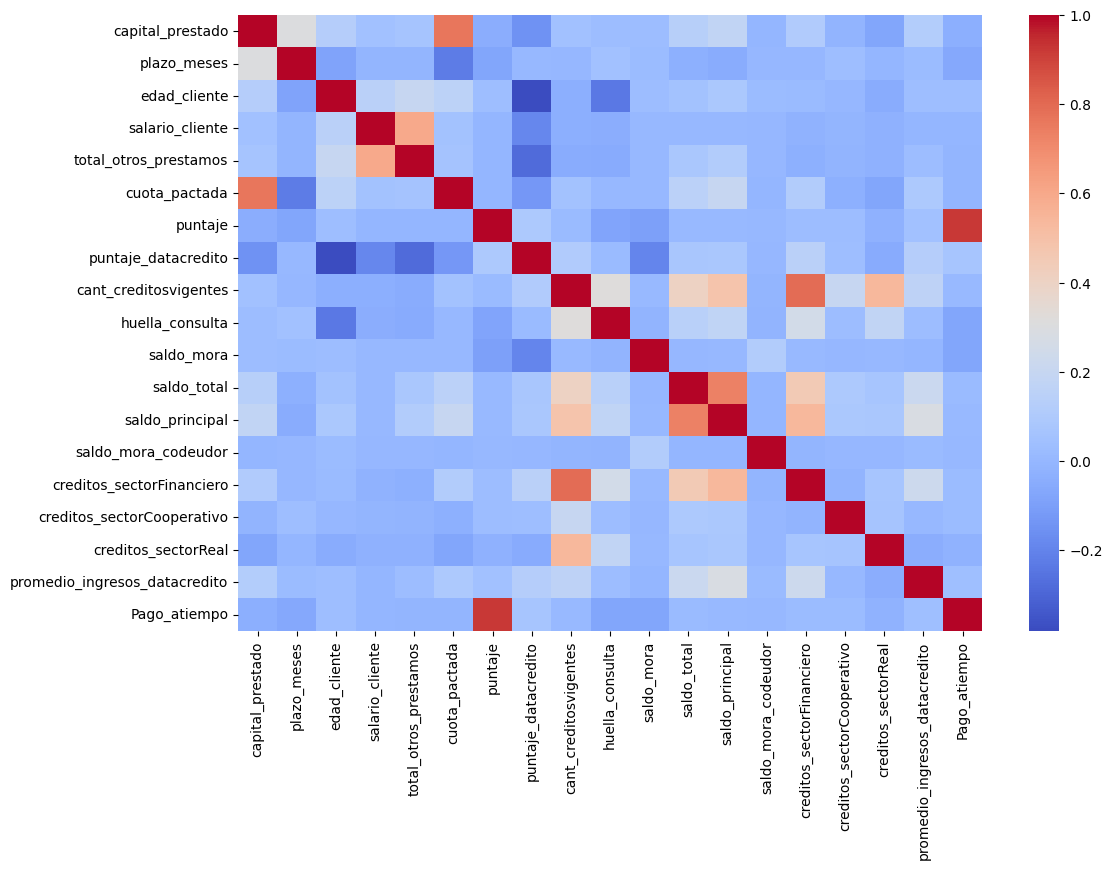

In [23]:
#Identificamos la multicolinealidad
# Se seleccionan solo variables numéricas
df_numeric = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,8))
sns.heatmap(df_numeric.corr(), annot=False, cmap='coolwarm')
plt.show()



In [24]:
#Nos muestra las correlaciones más altas excluyendo la diagonal
corr_matrix = df.select_dtypes(include='number').corr()

corr_matrix[(corr_matrix >= 0.75) & (corr_matrix < 1)]


,capital_prestado,plazo_meses,edad_cliente,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,Pago_atiempo
capital_prestado,NaN,NaN,NaN,NaN,NaN,0.764104,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
plazo_meses,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
edad_cliente,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salario_cliente,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_otros_prestamos,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cuota_pactada,0.764104,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
puntaje,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.923134
puntaje_datacredito,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cant_creditosvigentes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.791253,NaN,NaN,NaN,NaN
huella_consulta,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Se puede observar que existe una alta correlación (0.923134) entre la variable puntaje y la variable pago_atiempo, lo que puede indicar dos cosas, la primera es que esta es una relación esperada ya que el puntaje es un score de riesgo interno entonces el logico que esta este fuertemente correlacionada con el comportamiento de pago y la segunda es que la variable puntaje es muy dominante, lo que puede generar que el modelo se vuelva totalmente dependiente de esta y que las demás pierdan importancia y tambien se puede observar que existe una alta correlación (0.791253) entre la variable creditos_sectorFinanciero y la variable cant_creditosvigentes.

In [25]:
#Relación con la variable objetivo
df_numeric.corr()['Pago_atiempo'].sort_values(ascending=False)

,Pago_atiempo
Pago_atiempo,1.000000
puntaje,0.923134
puntaje_datacredito,0.067882
promedio_ingresos_datacredito,0.039867
edad_cliente,0.032252
creditos_sectorFinanciero,0.021390
creditos_sectorCooperativo,0.021267
saldo_total,0.014364
saldo_principal,0.011473
cant_creditosvigentes,0.008829


Se puede observar que todas las variables menos puntaje tienen una relación muy baja con la variable objetivo

In [26]:
#Prueba estadistica chi-cuadrado para visualizar las relaciones estadisticamente significativas (variables categoricas)
variables_categoricas = ['tipo_credito', 'tipo_laboral', 'tendencia_ingresos']

for var in variables_categoricas:
    print(f"\nVariable: {var}")

    tabla = pd.crosstab(df[var], df['Pago_atiempo'])

    chi2, p, dof, expected = chi2_contingency(tabla)

    print("Chi2:", chi2)
    print("p-value:", p)



Variable: tipo_credito
Chi2: 68.85672700245044
p-value: 1.772028551649206e-13

Variable: tipo_laboral
Chi2: 7.996822903394178
p-value: 0.004685949945647226

Variable: tendencia_ingresos
Chi2: 13.909122632568211
p-value: 0.0009542724729044392


Se puede observar que las variables categoricas dieron valores <0.05, lo que significa que estadisticamente tienen relación con nuestra variable objetivo pago_atiempo osea que no deben eliminarse

**Conclusión de eliminación de variables irrelevantes**

Según las metricas aplicadas anteriormente se tomo la decisión de eliminar las siguientes variables que se consideran irrelevantes:


*   saldo_total: Se decide eliminarla ya que esta es probablemente derivada de las columnas saldo_principal y saldo_mora
*   cant_creditosvigentes: Se decide eliminarla ya que esta es probablemente derivada de las columnas creditos_sectorFinancier, creditos_sectorReal y creditos_sectorCooperativo, además porque en la matriz de correlación esta presentó una alta correlación con la columna creditos_sectorFinanciero (0,79)


*   promedio_ingresosdatacredito: Se decide eliminarla ya que esta variable presenta más del 15% de valores nulo y cuando se supera este % no es recomendable imputar dichos valores
*   tendencia_ingresos: Se decide eliminarla ya que esta
variable presenta más del 15% de valores nulo y cuando se supera este % no es recomendable imputar dichos valores


*   puntaje: Se decide eliminar esta variable ya que esta presenta una alta relación con la variable objetivo (0,92) generando probablemnte que el modelo futuro dependa totalmente de esta esta variable para predecir convirtiendo así irrelenvantes las demás variables predictoras







In [27]:
#Eliminación de variables irrelevantes
columnas_eliminar = [
    "saldo_total",
    "cant_creditosvigentes",
    "promedio_ingresos_datacredito",
    "tendencia_ingresos",
    "puntaje"
]

df = df.drop(columns=columnas_eliminar)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   tipo_credito                10763 non-null  object        
 1   fecha_prestamo              10763 non-null  datetime64[ns]
 2   capital_prestado            10763 non-null  float64       
 3   plazo_meses                 10763 non-null  int64         
 4   edad_cliente                10763 non-null  int64         
 5   tipo_laboral                10763 non-null  object        
 6   salario_cliente             10763 non-null  int64         
 7   total_otros_prestamos       10763 non-null  int64         
 8   cuota_pactada               10763 non-null  int64         
 9   puntaje_datacredito         10757 non-null  float64       
 10  huella_consulta             10763 non-null  int64         
 11  saldo_mora                  10607 non-null  float64   

## **PARTE 3**

 **EDA**/ **Analisis Univariado**

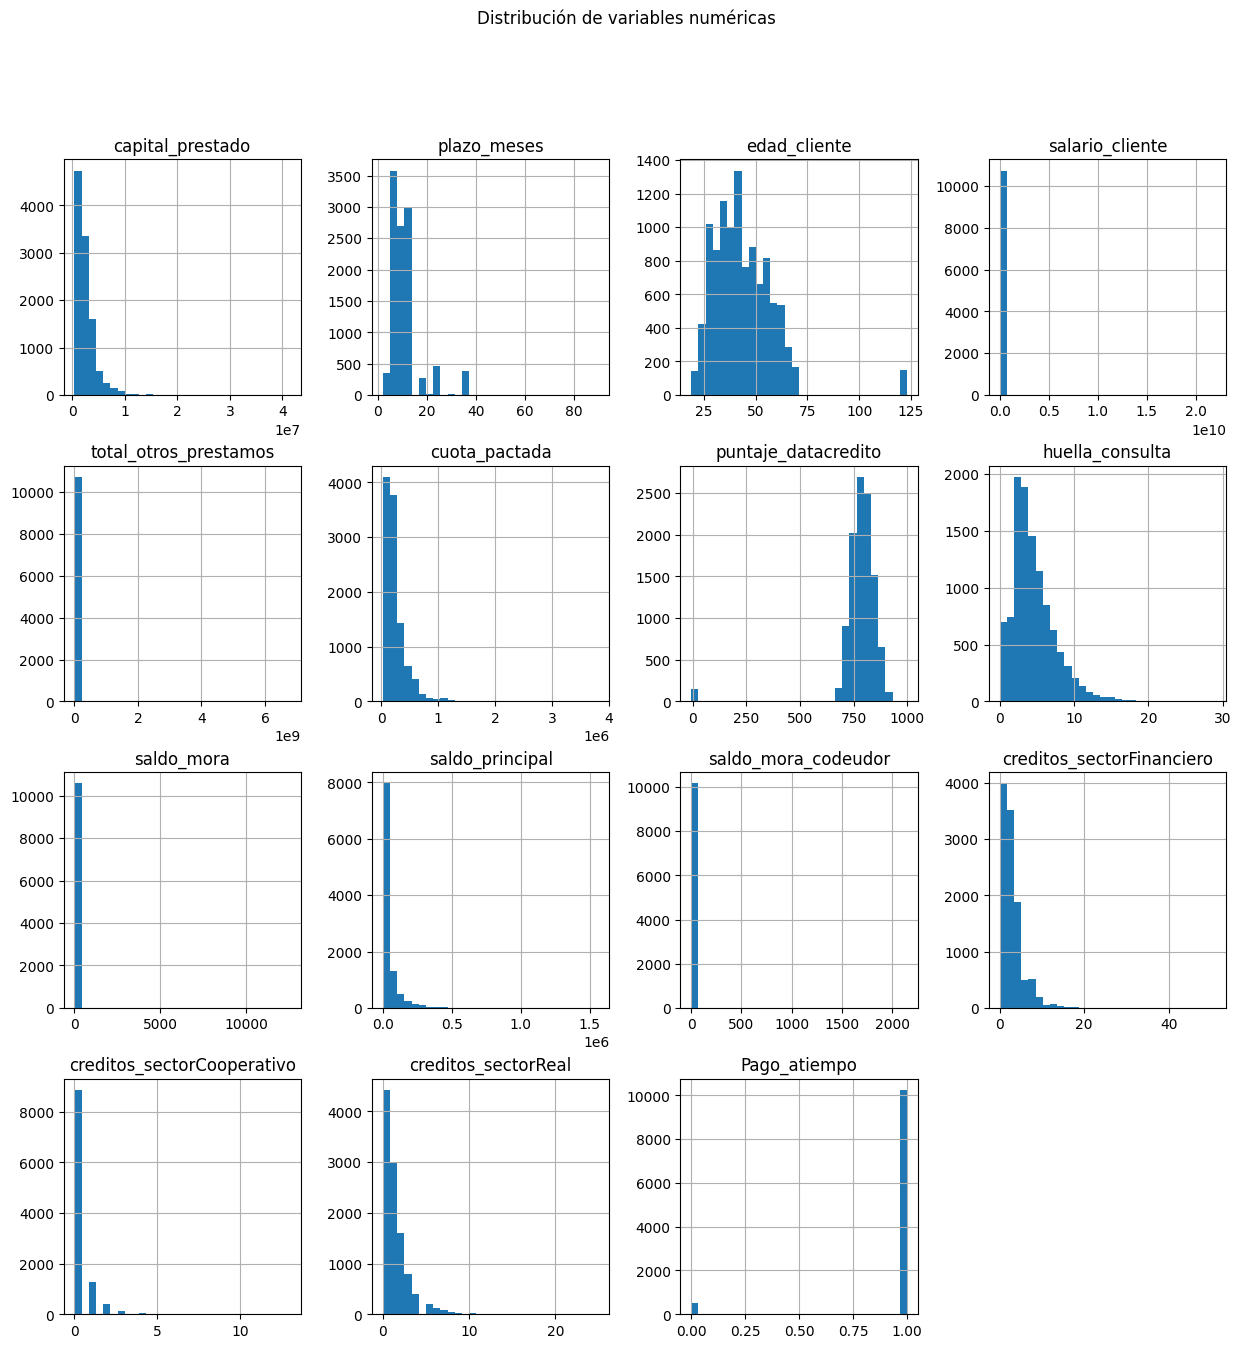

In [28]:
#Distribución de variables numéricas
df.select_dtypes(include=np.number).hist(figsize=(15,15), bins=30)
plt.suptitle('Distribución de variables numéricas')
plt.show()

En los graficos anteriores se puede observar lo siguiente:


*   plazo_meses: Que los créditos que brinda la entidad financiera son de corto plazo ( 6-12 meses)
*   edad_cliente: La gran mayoría de los clientes del banco tienen edades entre los 25 y 40 años


*   puntaje_datacredito: La mayoría de los clientes del banco cuentan con un alto score pero hay algunos que cuentan con un score de 0 indicando probablemente que aún no han comenzado con su vida crediticia
*   huella_consulta: La mayoría de los clientes tienen uuna cantidad de huella consulta entre 0 y 10 lo que indica que la mayoría de los clientes tienen una huella consulta alta indicando una alta probabilidad de riesgo









In [29]:
#Discriminación de las variables numéricas
numericas = df.select_dtypes(include='number').columns

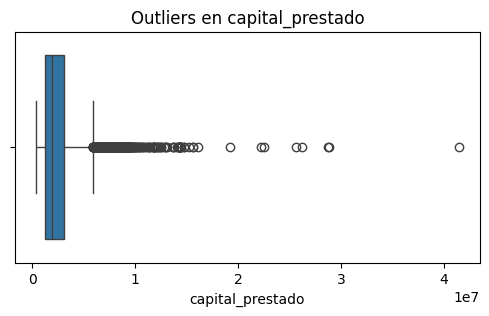

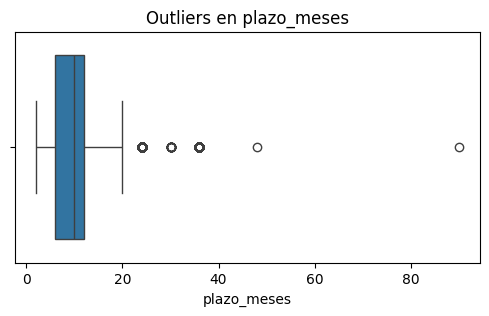

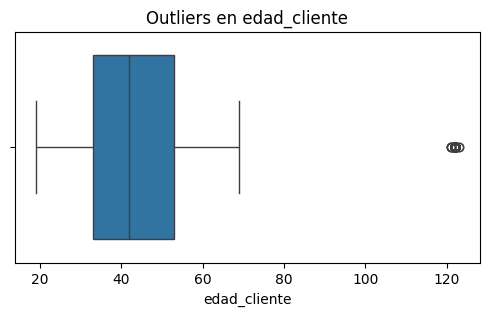

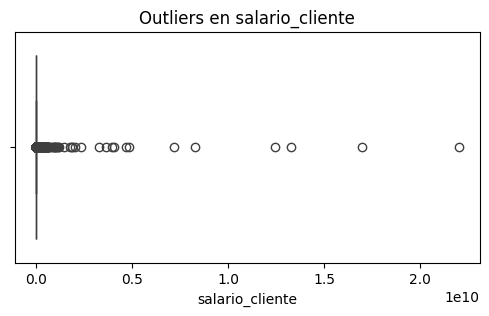

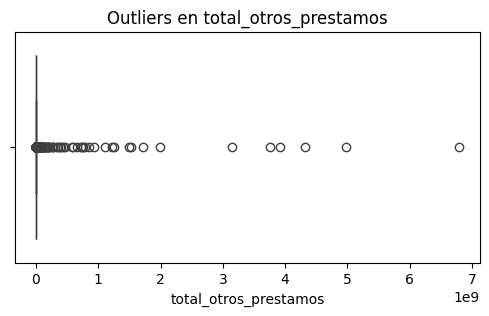

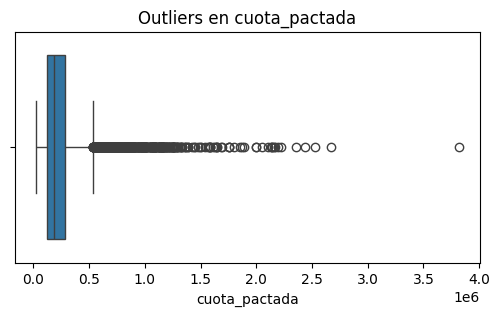

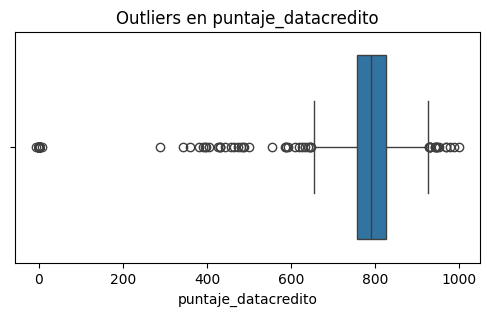

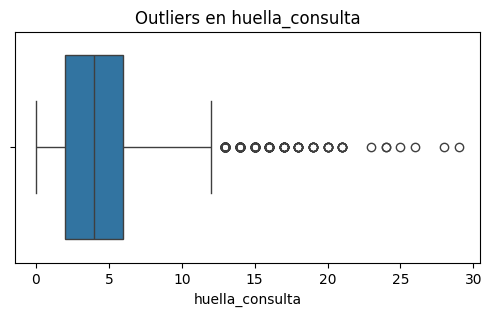

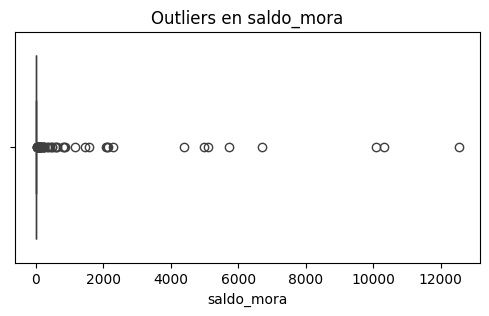

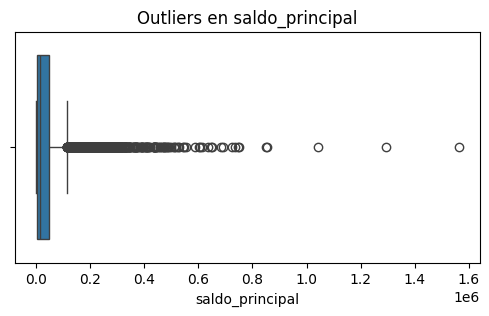

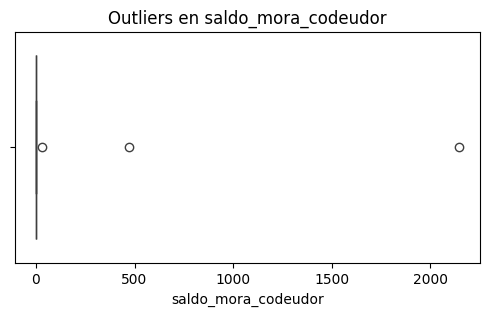

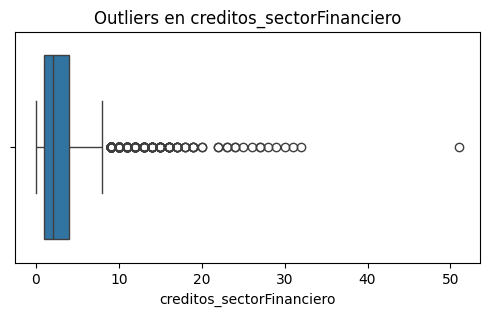

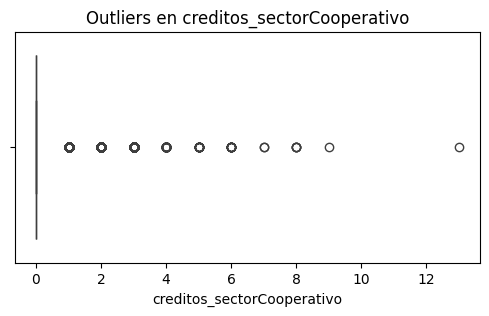

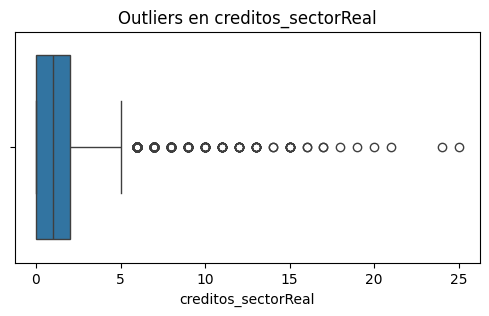

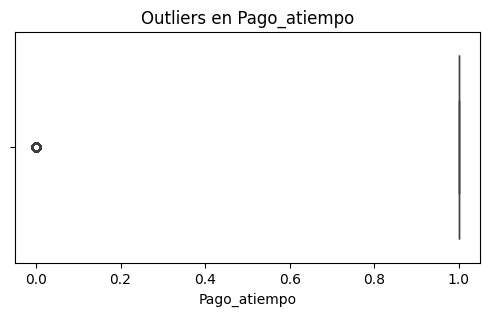

In [30]:
#Detección de outliers variables numéricas


for col in numericas:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Outliers en {col}")
    plt.show()

Con el grafico de boxplot se pudieron identificar los siguientes posibles outliers en el dataset:


*   edad_cliente: Podemos observar que la edad de los clientes del banco comienzan en 19 (min) y la edad maxima es de 123 años (max) lo cual es improbable
*   salario_cliente: Podemos observar que la mayoría del salario de los cliente se mueve entre 0 y 0,5 (poner los valores en pesos), pero existen algunos valores de salarios que llegan hasta los 20'000.000.000 lo cual es improbable


*   total_otros_prestamos: Se puede observar que existen algunos valores de otros prestamos del valor de 7'000.000.000 lo que puede indicar que hay clientes altamente sobreendeudados o posibles outliers
*   puntaje_datacredito: Se puede observar que esta variable presenta outliers ya que tenemos valores minimos de -7 y valores maximos de 999, teniendo en cuenta que los puntajes en datacrecito oscilan entre los 150-950 puntos



*   huella_consulta: Se puede observar que algunos de los clientes presenta huellas consulta desde 15 hasta 30 lo que indica que han tenido un alto volumen de verificaciones incrementando el riesgo





In [31]:
#Descripción estadística completa
stats = df[numericas].agg([
    "mean","median","min","max","std","var","skew","kurt"
]).T

stats["rango"] = stats["max"] - stats["min"]

stats

,mean,median,min,max,std,var,skew,kurt,rango
capital_prestado,2.434315e+06,1921920.0,360000.0,4.144415e+07,1.909643e+06,3.646735e+12,3.723884,35.318092,4.108415e+07
plazo_meses,1.057558e+01,10.0,2.0,9.000000e+01,6.632082e+00,4.398451e+01,2.459691,7.780121,8.800000e+01
edad_cliente,4.394862e+01,42.0,19.0,1.230000e+02,1.506088e+01,2.268300e+02,1.934399,7.868936,1.040000e+02
salario_cliente,1.721643e+07,3000000.0,0.0,2.200000e+10,3.554767e+08,1.263637e+17,43.776664,2211.230120,2.200000e+10
total_otros_prestamos,6.238870e+06,1000000.0,0.0,6.787675e+09,1.184183e+08,1.402290e+16,38.463886,1719.280871,6.787675e+09
cuota_pactada,2.436174e+05,182863.0,23944.0,3.816752e+06,2.104937e+05,4.430760e+10,3.793301,26.650757,3.792808e+06
puntaje_datacredito,7.807908e+02,791.0,-7.0,9.990000e+02,1.048780e+02,1.099940e+04,-5.644513,39.437798,1.006000e+03
huella_consulta,4.228561e+00,4.0,0.0,2.900000e+01,3.064683e+00,9.392282e+00,1.487102,3.998984,2.900000e+01
saldo_mora,7.746017e+00,0.0,0.0,1.253400e+04,2.259551e+02,5.105572e+04,40.568483,1845.712807,1.253400e+04
saldo_principal,4.034617e+04,14442.5,0.0,1.562285e+06,7.124244e+04,5.075485e+09,5.050172,51.063839,1.562285e+06


Gracias a este análisis estadistico podemos observar que existen variables con skew y kurtosos muy altas como:


*   salario_cliente
*   total_otros_prestamos
*   saldo_mora
*   saldo_mora_codeudor
*   saldo_principal

Estas variables necesitan de diferentes transformaciones para que puedan ser de gran valor para el modelo





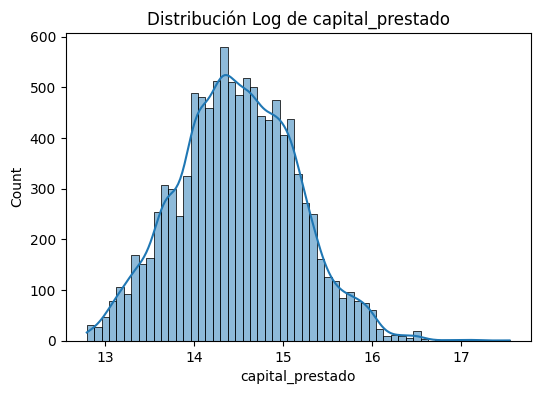

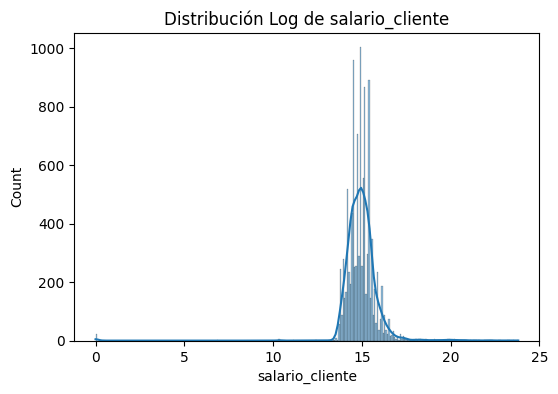

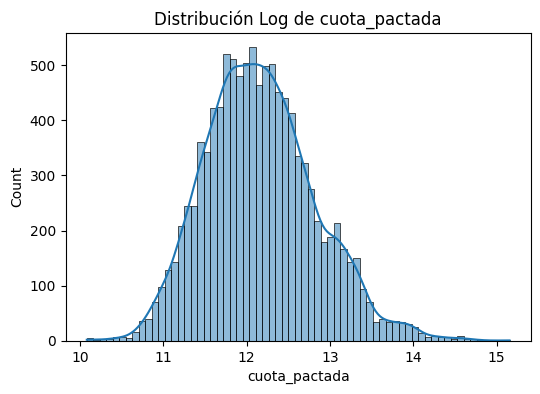

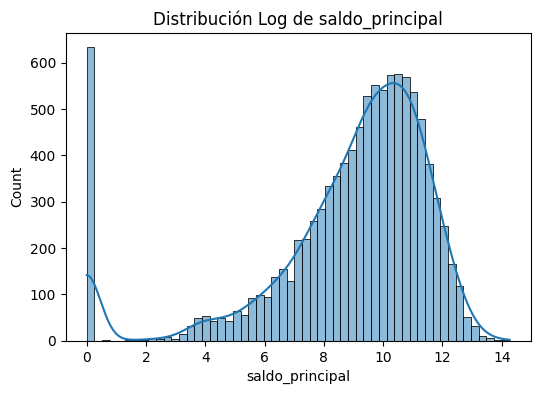

In [32]:
#Distribución logarítmica
cols_log = ["capital_prestado","salario_cliente","cuota_pactada","saldo_principal"]

for col in cols_log:
    plt.figure(figsize=(6,4))
    sns.histplot(np.log1p(df[col]), kde=True)
    plt.title(f"Distribución Log de {col}")
    plt.show()


In [33]:
#Variables categoricas
cat_cols = df.select_dtypes(include= 'object').columns
for col in cat_cols:
  print(f'Columna: {col}')
  print(df[col].value_counts(dropna=False))


Columna: tipo_credito
tipo_credito
4     7747
9     2876
10     116
6       21
7        2
68       1
Name: count, dtype: int64
Columna: tipo_laboral
tipo_laboral
Empleado         6754
Independiente    4009
Name: count, dtype: int64


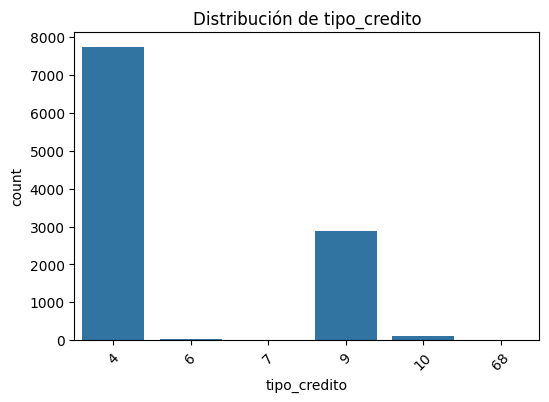

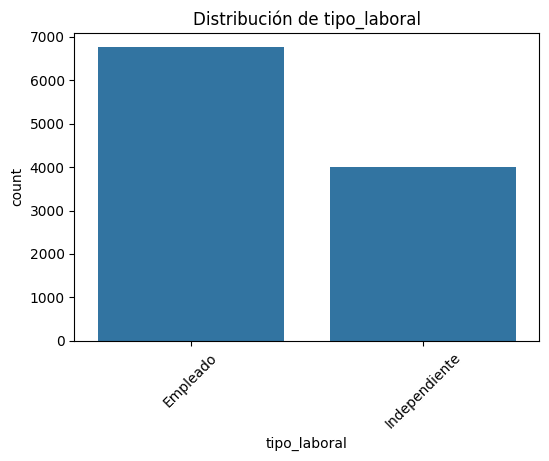

In [34]:
#Countplot variables numéricas
for col in ["tipo_credito","tipo_laboral"]:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col)
    plt.title(f"Distribución de {col}")
    plt.xticks(rotation=45)
    plt.show()


Se puede observar que:


*   tipo_credito: Los clientes prefieren tomar el tipo de crédito #4 o el banco prefiere otorgrar el crédito #4 teniendo en cuenta el peril del cliente
*   tipo_laboral: La gran mayoría de los clientes del banco son empleados



**EDA/ ANALISIS BIVARIADO**

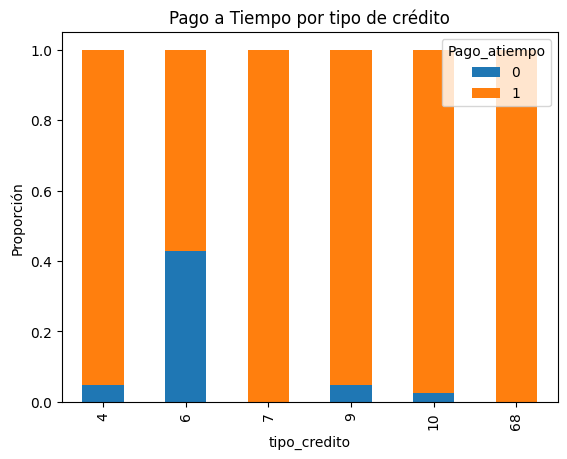

In [35]:
#Variables categoricas vs pago_atiempo
pd.crosstab(df["tipo_credito"], df["Pago_atiempo"], normalize="index").plot(kind="bar", stacked=True)
plt.title("Pago a Tiempo por tipo de crédito")
plt.ylabel("Proporción")
plt.show()


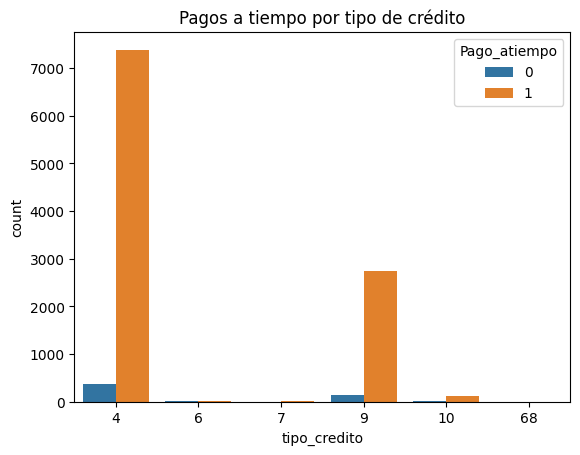

In [36]:
#Distribución de pagos a tiempo por tipo de crédito
sns.countplot(data=df, x='tipo_credito',hue='Pago_atiempo')
plt.title('Pagos a tiempo por tipo de crédito')
plt.show()

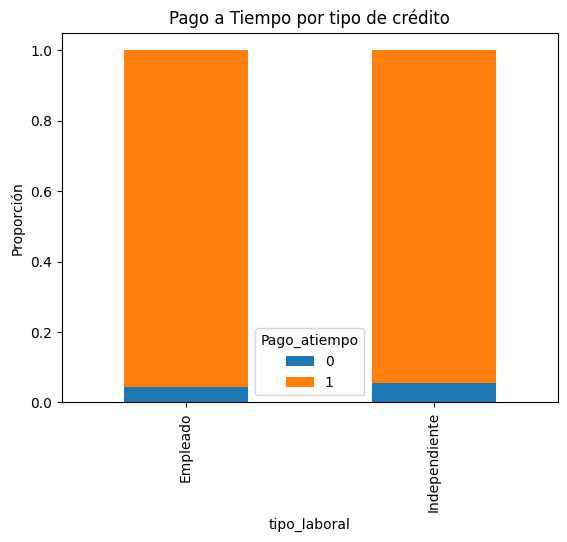

In [37]:
pd.crosstab(df["tipo_laboral"], df["Pago_atiempo"], normalize="index").plot(kind="bar", stacked=True)
plt.title("Pago a Tiempo por tipo de crédito")
plt.ylabel("Proporción")
plt.show()

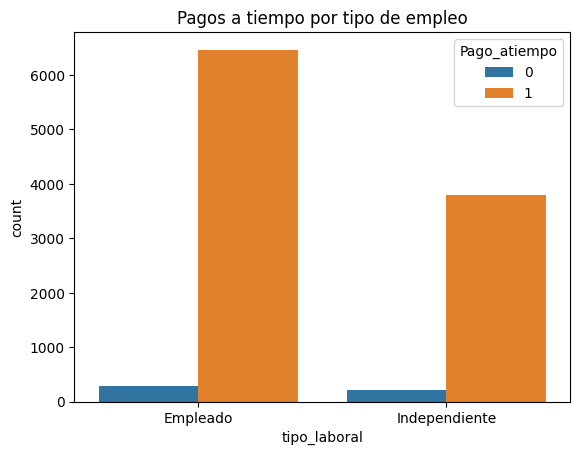

In [38]:
#Distribución de pago a tiempo por tipo de empleo
sns.countplot(data=df, x='tipo_laboral',hue='Pago_atiempo')
plt.title('Pagos a tiempo por tipo de empleo')
plt.show()

Se puede observar que la gran mayoría de clientes según el tipo de crédito que tengan y el tipo de empleo que tengan pagan a tiempo, pero este comportamiento tal vez se deba a que la variable objetivo esta notoriamente desbalanceada obteniendo como clase mayoritaría 1 (paga) y como clase minoritaría 0 (no paga)

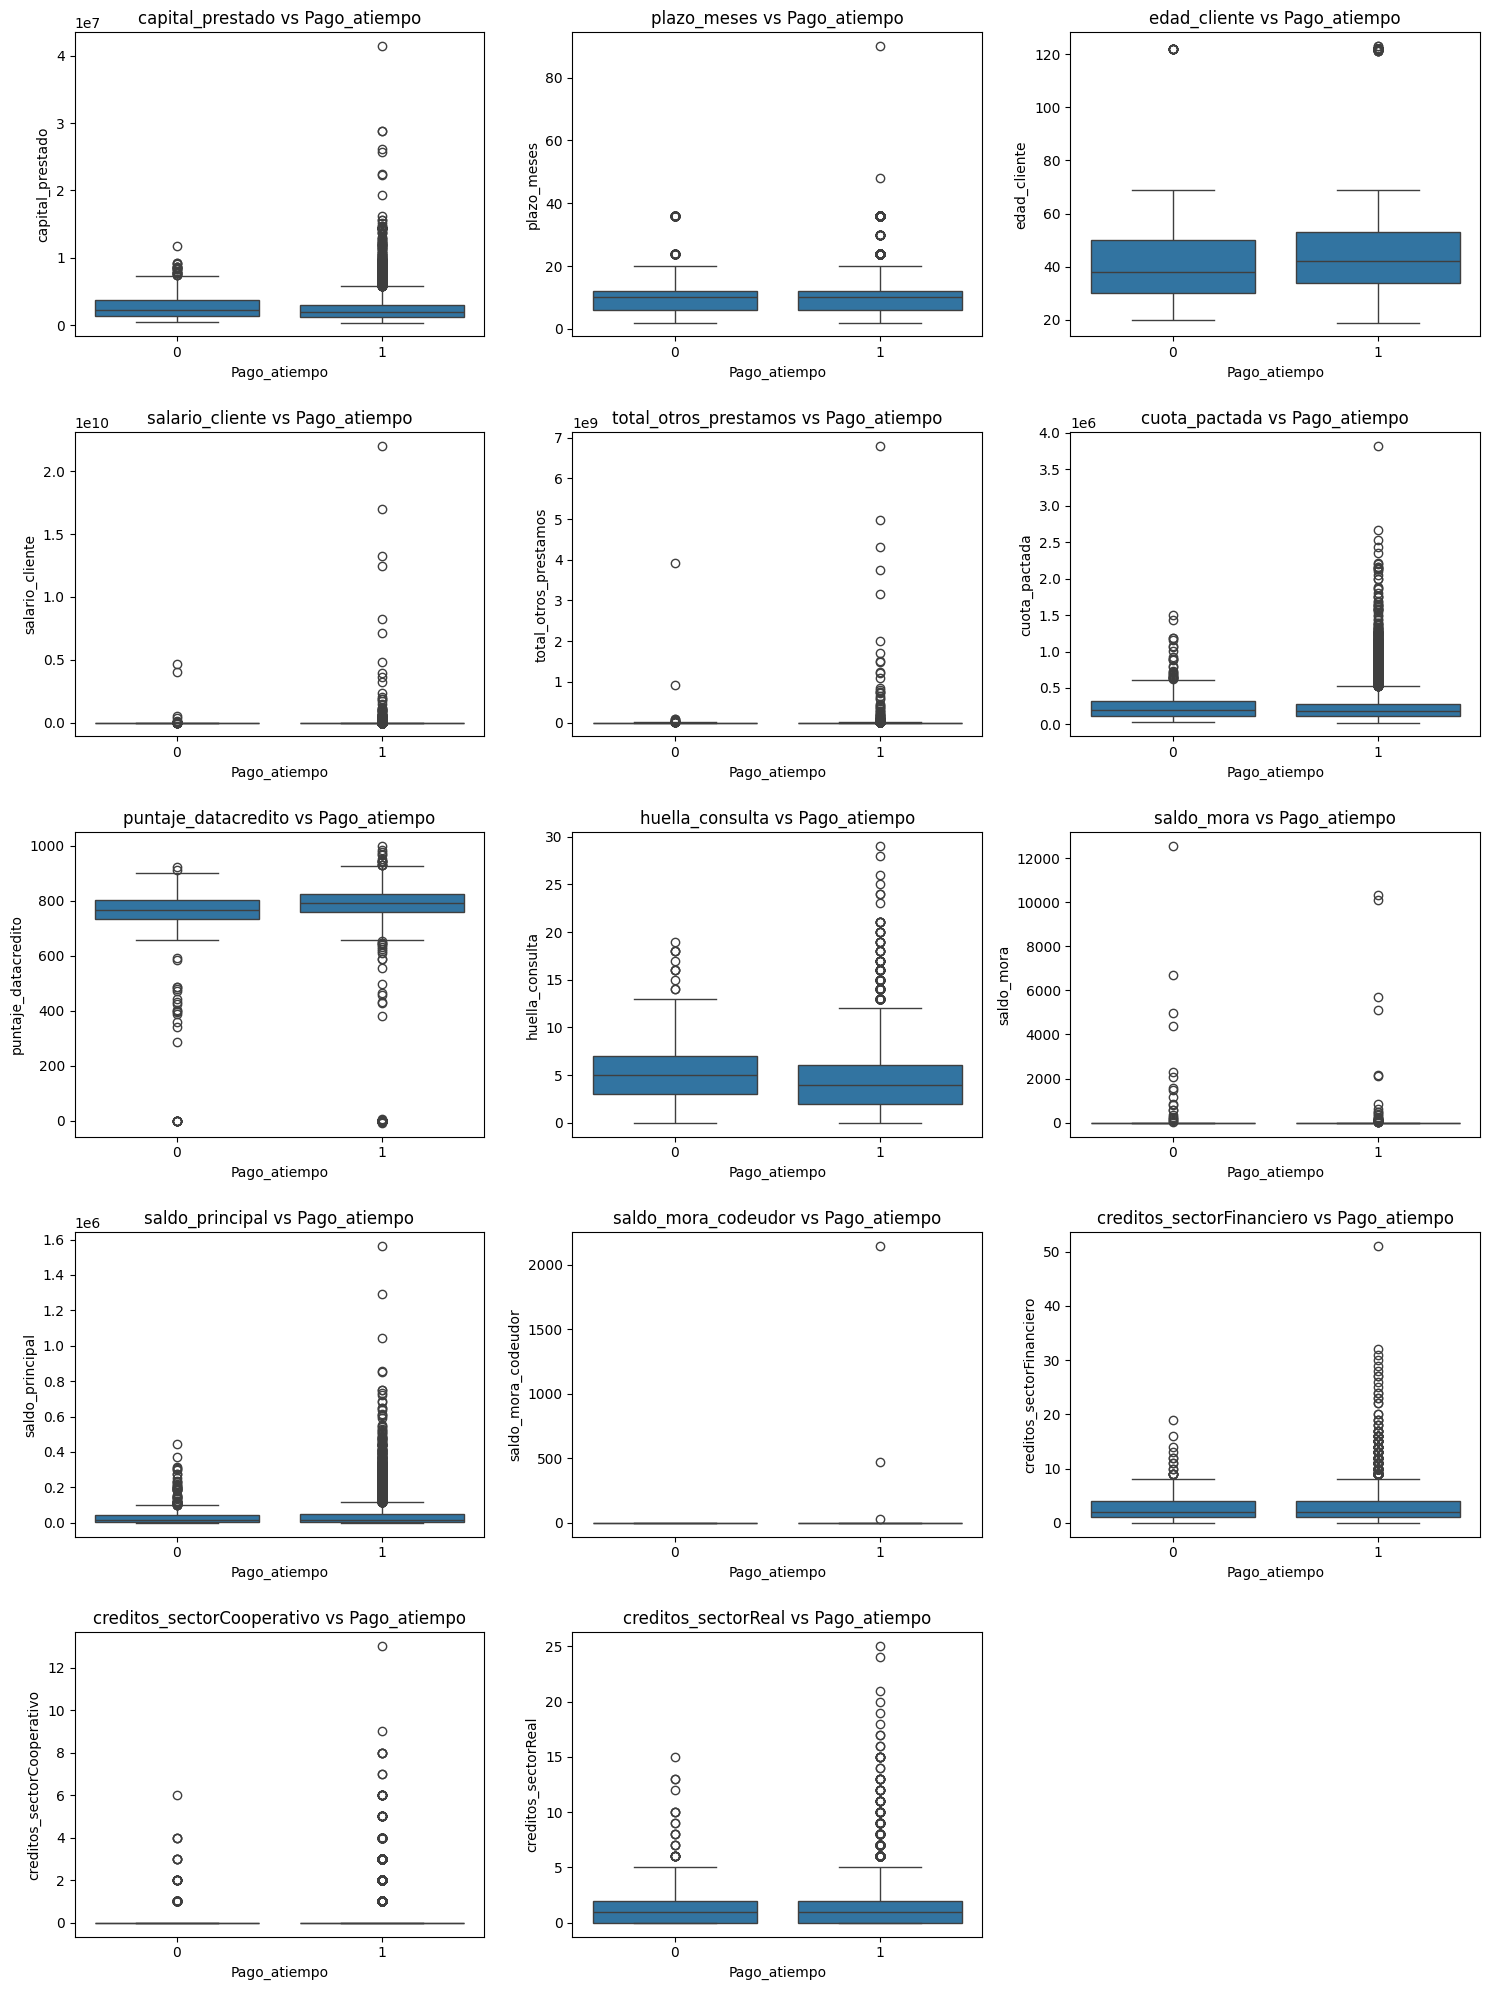

In [39]:
#Variables numéricas vs pago_atiempo
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

num_cols = [col for col in num_cols if col != "Pago_atiempo"]

n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(5*n_cols, 4*n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x="Pago_atiempo", y=col, data=df)
    plt.title(f"{col} vs Pago_atiempo")

plt.tight_layout()
plt.show()


En los boxplot de variables numéricas vs variable objetivo podemos observar que:


*   puntaje_datacredito vs pago_atiempo: Se puede observar que la mediana de 1 (pago) es más alta que la mediana de 0 (no pago) lo que indica que clientes con mayor puntaje son aquellos que tienden a pagar
*   huella_consulta vs paga_atiempo: Se puede observar que la mediana de 1 (pago) esta más abajo que la mediana de 0 (no pago) lo que indica que clientes con menores numéros de huella consulta son aquellos que tiendes a pagar

*   edad_cliente vs pago_atiempo: Se puede observar que la media de 1(pago) es más alta que la mediana de 0 (no pago) lo que indica que los clientes que son mayores de 40 años son aquellos que tienen a pagar, lo que indica a su vez que probablemente los clientes jovenes representen un riesgo
*   Elemento de lista





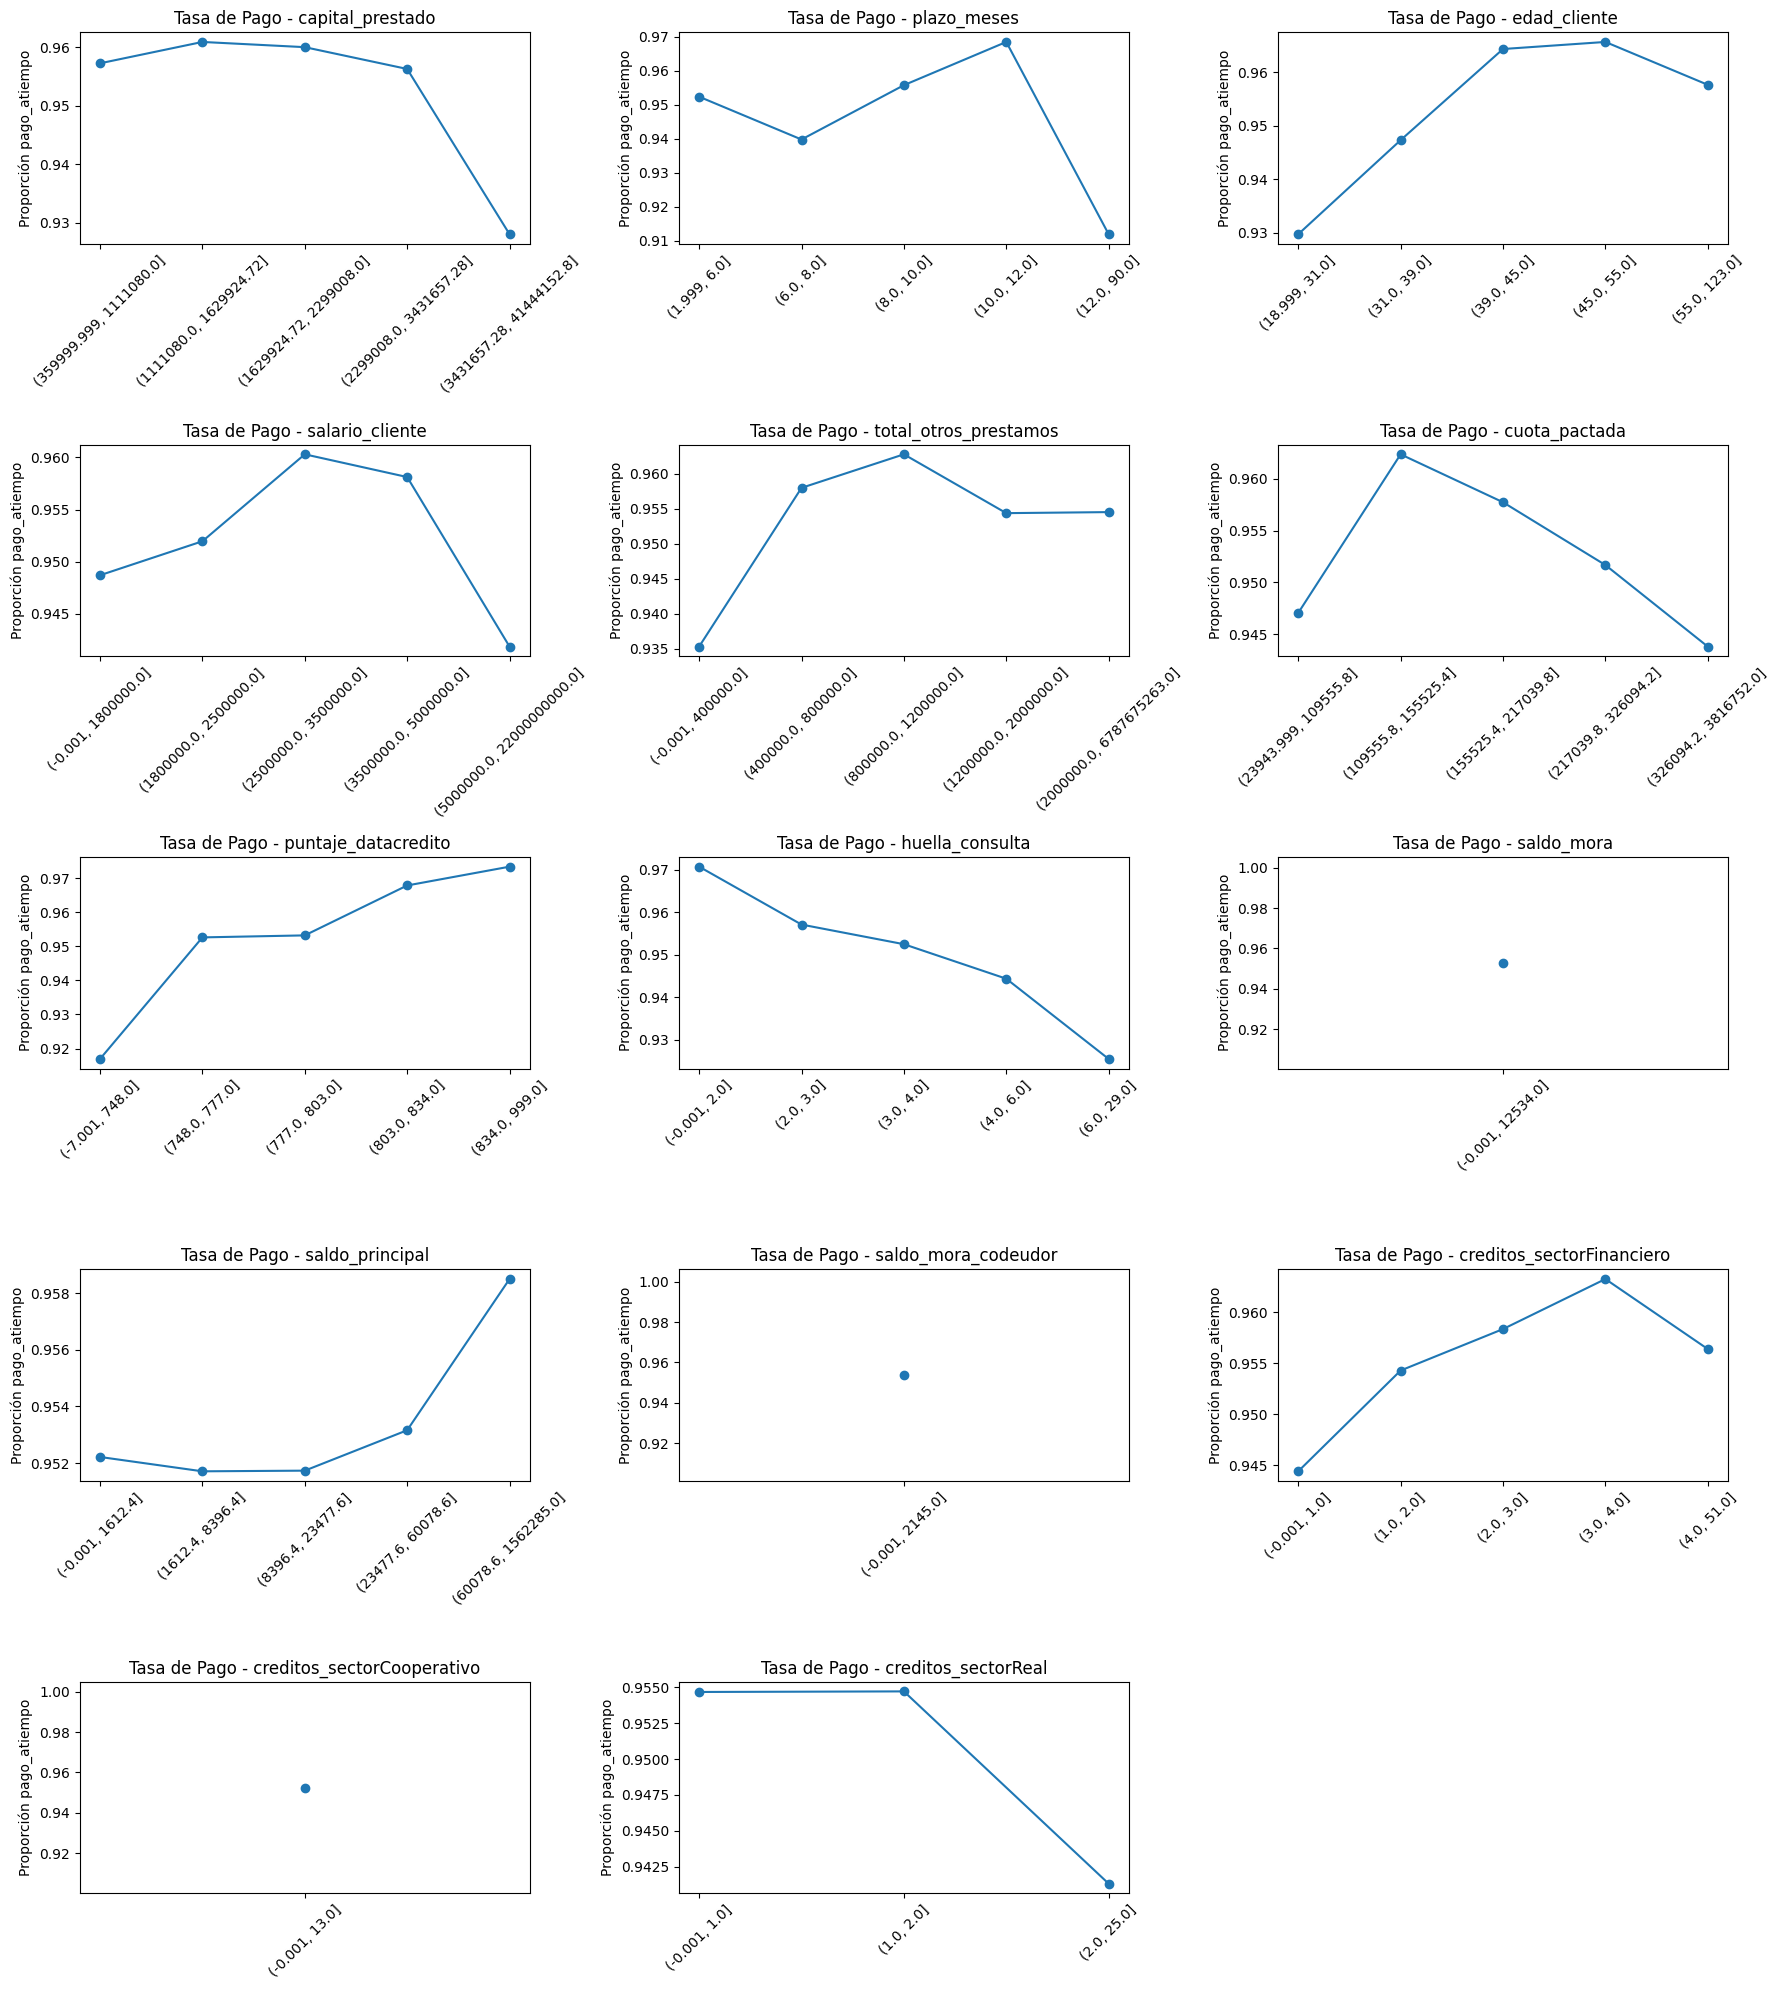

In [40]:
#Curva de tasa de evanto
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
num_cols = [col for col in num_cols if col != "Pago_atiempo"]

n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(6*n_cols, 4*n_rows))

for i, col in enumerate(num_cols, 1):

    temp = df[[col, "Pago_atiempo"]].copy()

    # Eliminar nulos
    temp = temp.dropna()

    try:
        # Crear quintiles
        temp["bin"] = pd.qcut(temp[col], 5, duplicates="drop")

        # Calcular tasa de evento (pago a tiempo = 1)
        tasa = pd.crosstab(temp["bin"], temp["Pago_atiempo"], normalize="index")

        # Graficar
        plt.subplot(n_rows, n_cols, i)
        plt.plot(tasa.index.astype(str), tasa[1], marker="o")
        plt.xticks(rotation=45)
        plt.title(f"Tasa de Pago - {col}")
        plt.ylabel("Proporción pago_atiempo")

    except:
        continue

plt.tight_layout()
plt.show()


Gracias al grafico de curva de tasa de evento podemos observar que:


*   tasa de pago capital_prestado: Se observa que a mayor capital prestado menor es la probabilidad de pago por parte del cliente
*   tasa de pago saldo_principal: Se observa que a mayor capital pendiente por pagar mayor es la probabilidad de pago por parte del cliente

*   tasa de pago edad_cliente: Se confirma la hipotesis del grafico anterior, se observa que a mayor edad del cliente mayor es la probabilidad de pago por parte del cliente
*   tasa de pago plazo_meses: Se observa que a mayor plazo para pagar el credito en mese menor es la probabilidad de pago por parte del cliente



 **EDA/ ANALISIS MULTIVARIADO**

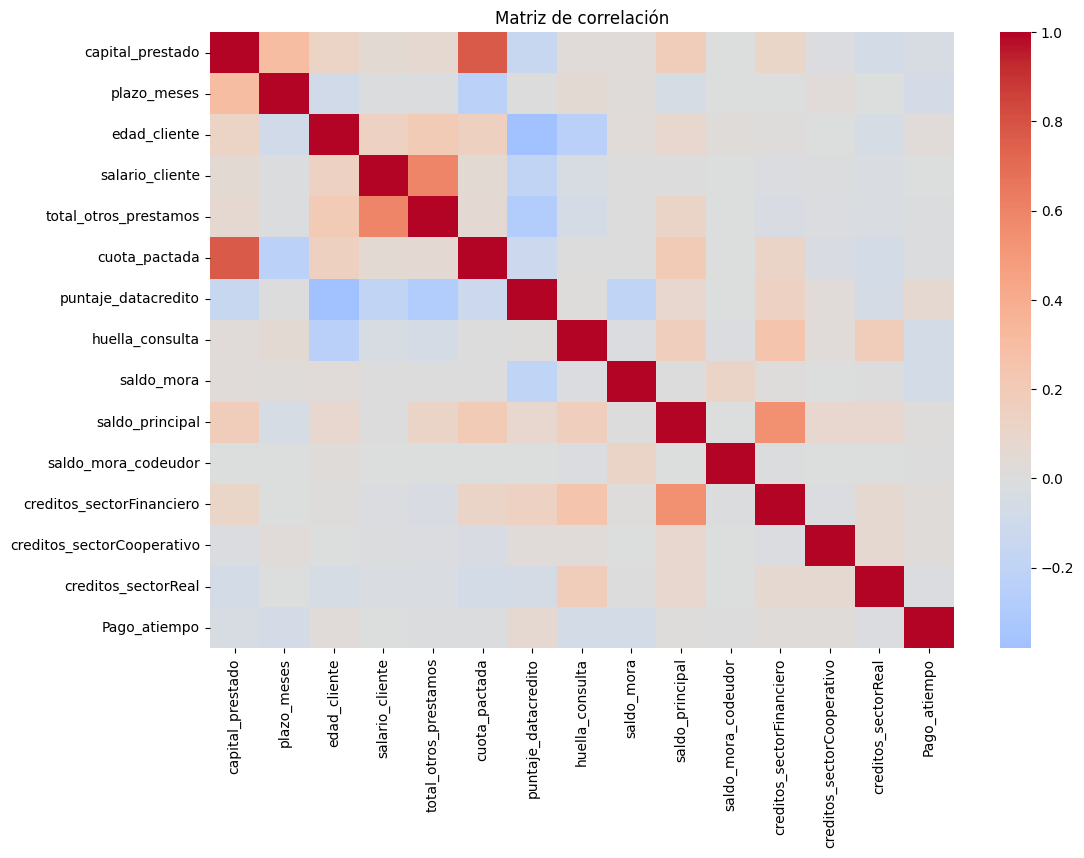

In [41]:
#Matriz de correlación variables numéricas vs variables numéricas
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.show()


In [42]:
#Nos muestra las correlaciones más altas excluyendo la diagonal
corr_matrix = df.select_dtypes(include='number').corr()

corr_matrix[(corr_matrix >= 0.75) & (corr_matrix < 1)]

,capital_prestado,plazo_meses,edad_cliente,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje_datacredito,huella_consulta,saldo_mora,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,Pago_atiempo
capital_prestado,NaN,NaN,NaN,NaN,NaN,0.764104,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
plazo_meses,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
edad_cliente,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salario_cliente,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_otros_prestamos,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cuota_pactada,0.764104,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
puntaje_datacredito,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
huella_consulta,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
saldo_mora,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
saldo_principal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


En la matriz de correlación podemos observar una alta correlación de la variable cuota_pactada con la variable capital_prestado, pero el valor de la correlación de 0.764 lo que indica una correlación normal o media entre estas dos variables

In [43]:
#Seleccionamos solo las variables más importantes con nuestra variable objetivo
# Correlación con la variable objetivo
corr_target = df.corr(numeric_only=True)["Pago_atiempo"].abs().sort_values(ascending=False)

# Tomar las 6 más importantes (ajusta el número si quieres)
top_vars = corr_target.index[1:7]  # excluye pago_atiempo

top_vars



Index(['huella_consulta', 'saldo_mora', 'puntaje_datacredito', 'plazo_meses',
       'capital_prestado', 'edad_cliente'],
      dtype='object')

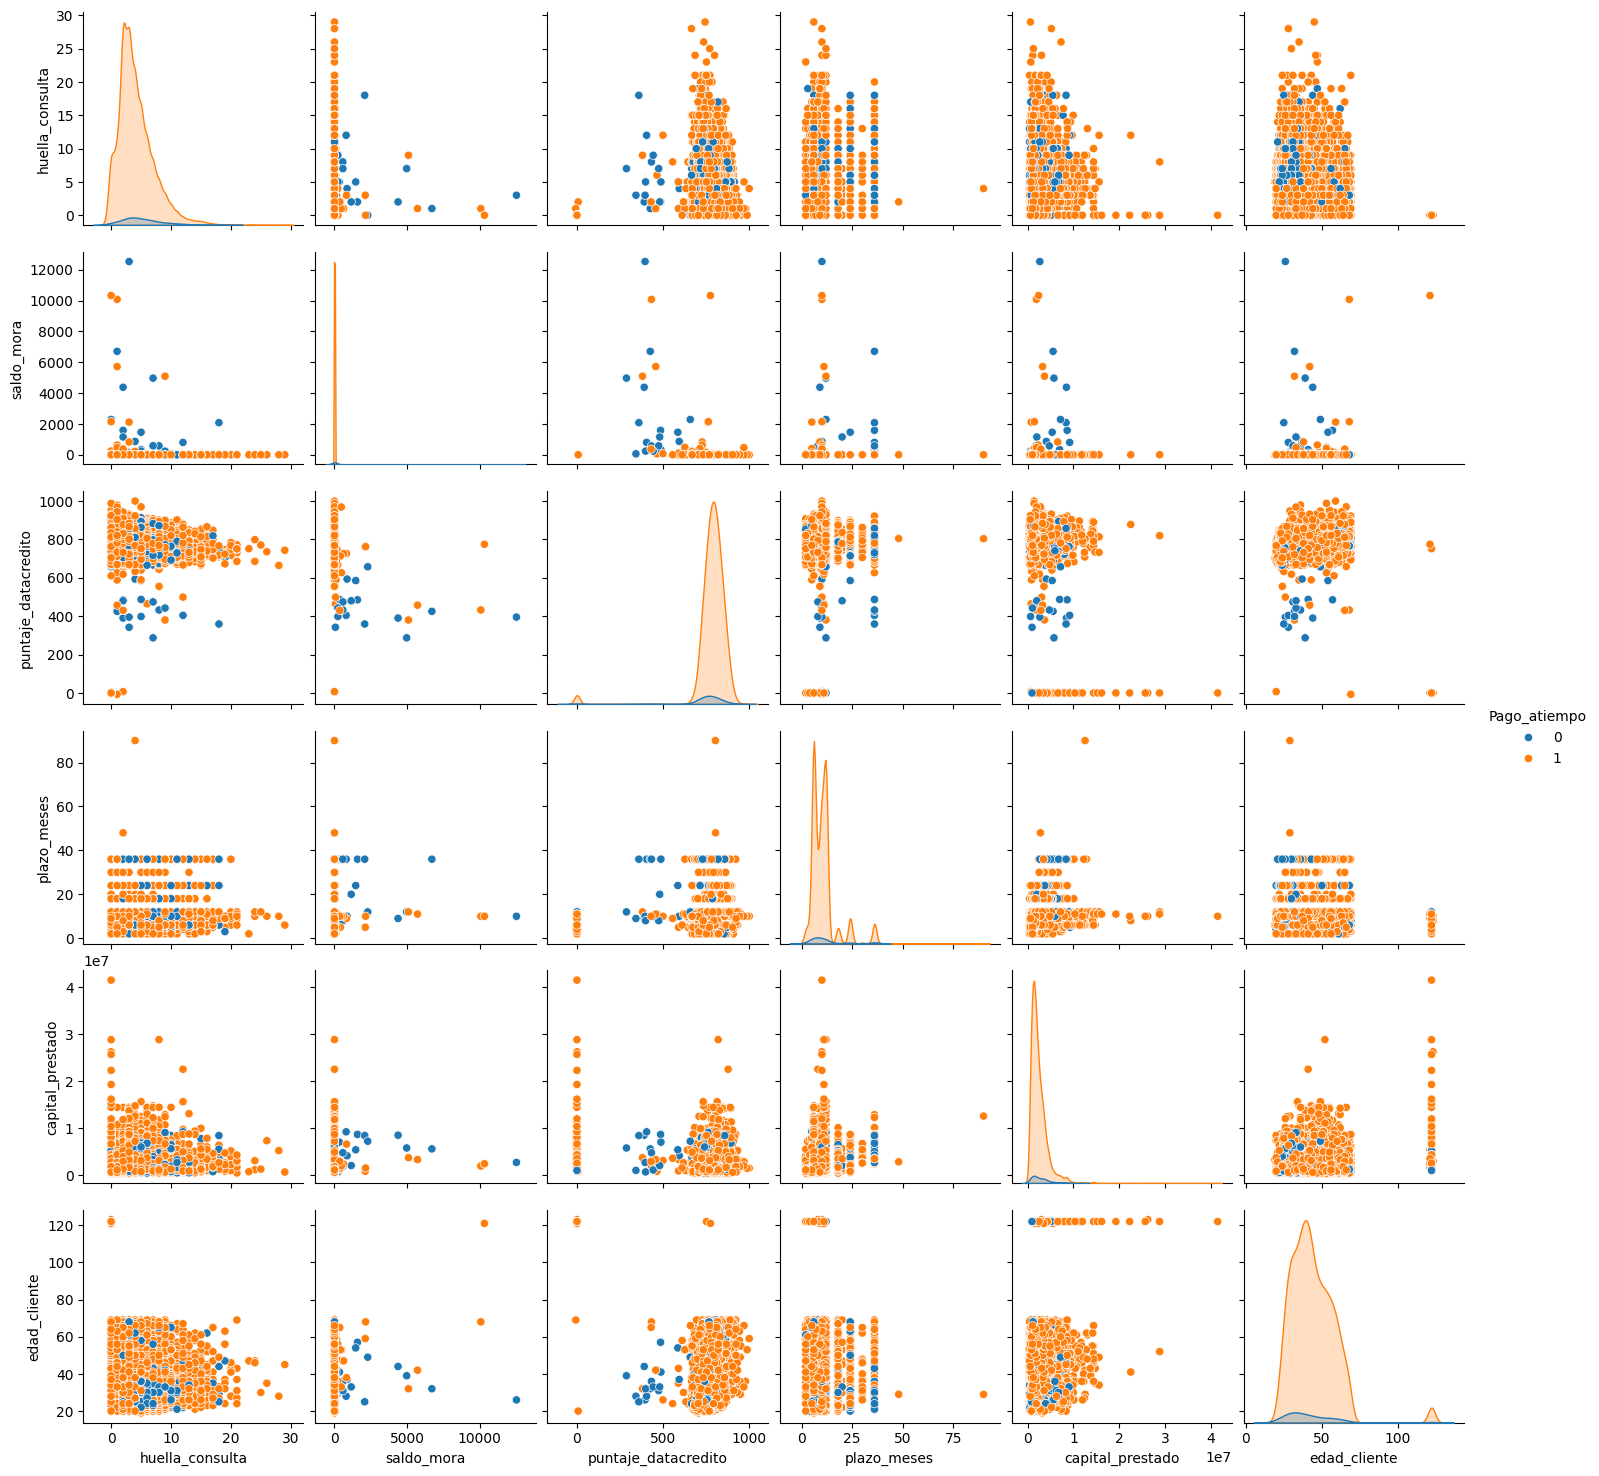

In [44]:
#Exploración visual profuenda con pairplot
sns.pairplot(
    df[list(top_vars) + ["Pago_atiempo"]],
    hue="Pago_atiempo",
    diag_kind="kde"
)
plt.show()


Gracias Pairplot podemos observar:


*  edad_cliente vs huella_consulta: Se puede observar que mientras más joven es el cliente y tenga una huella consulta entre 5 a 10 tiende a no pagar.
*   Elemento de lista



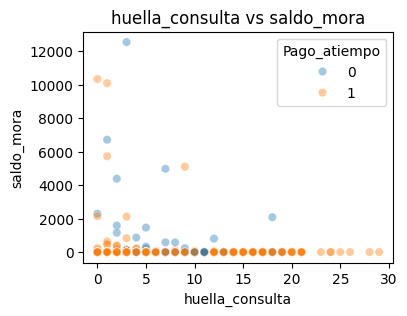

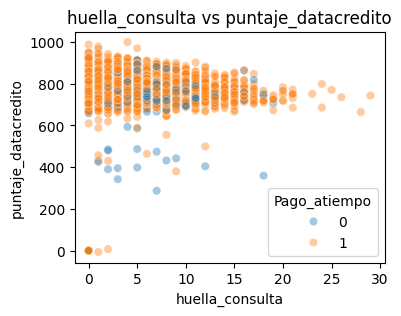

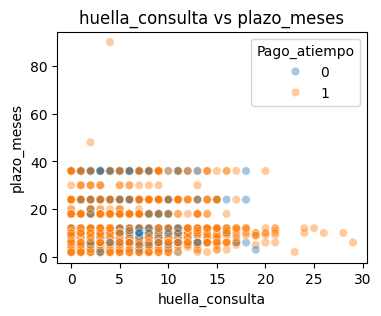

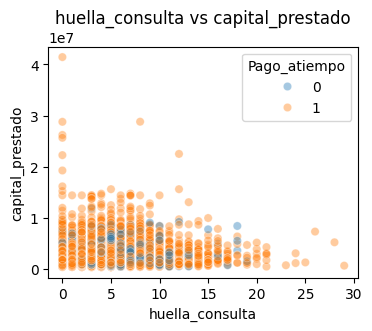

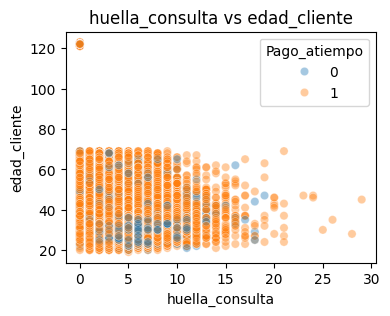

In [45]:
#Scatter plot contra las variables más importantes
var_principal = top_vars[0]

for var in top_vars[1:]:
    plt.figure(figsize=(4,3))
    sns.scatterplot(
        data=df,
        x=var_principal,
        y=var,
        hue="Pago_atiempo",
        alpha=0.4
    )
    plt.title(f"{var_principal} vs {var}")
    plt.show()


En los scatterplots se pueden observar y confirmar tendencias que ya se habían identificado en análisis anteriores como:


*   edad_cliente vs huella_consulta: Se puede observar que la gran cantidad de clientes están representados dentro de un rango de 20 a 65 años con un número de hullas consultas de 0 a 10, obteniendo que las perosnas que son más jovenes y tienen una huella consulta entre 5-6 tienden a no pagar a tiempo
*   huella_consulta vs puntaje_datacredito: Se puede observar que a menor huella consulta y a mayor puntaje data credito el cliente tiende a pagar a tiempo pero tambien podemos observar que en algunos casos en donde el putaje datacredito es bajo pero la huella consulta tambien es baja el riesgo de que el cliente tienda a no pagar a tiempo aumenta.


*   huella_consulta vs plazo_meses: Se puede observar que a menor cantidad de plazo en meses y menor cantidad número de huellas consultas el cliente tiende a pagar a tiempo en su mayoría






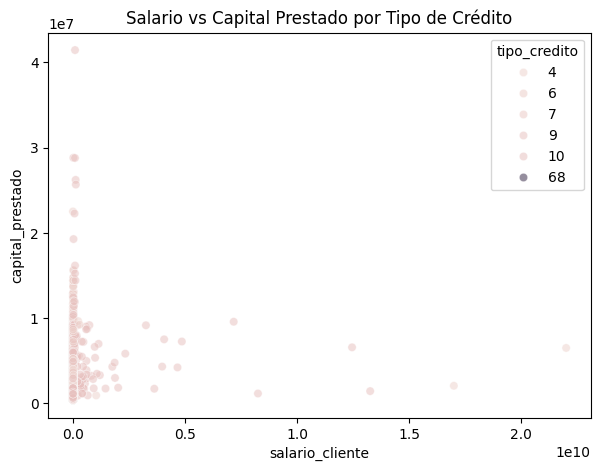

In [46]:
#Variables categoricas
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x="salario_cliente",
    y="capital_prestado",
    hue="tipo_credito",
    alpha=0.5
)
plt.title("Salario vs Capital Prestado por Tipo de Crédito")
plt.show()


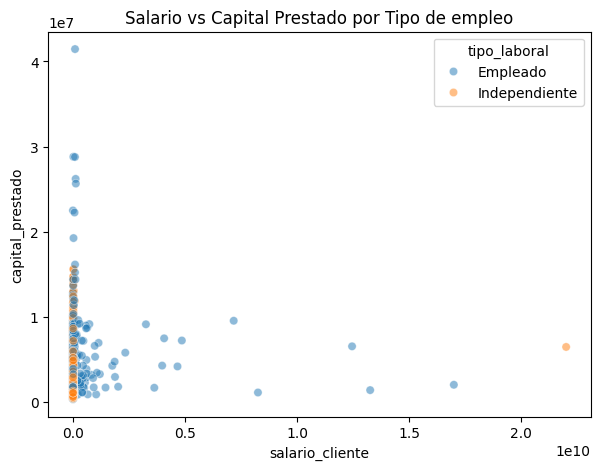

In [47]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x="salario_cliente",
    y="capital_prestado",
    hue="tipo_laboral",
    alpha=0.5
)
plt.title("Salario vs Capital Prestado por Tipo de empleo")
plt.show()


In [48]:
#Saber si una persona pago a tiempo según el tipo de crédtio que obtuvo y el tipo de empleo que tiene
pd.crosstab(
    [df["tipo_laboral"], df["tipo_credito"]],
    df["Pago_atiempo"],
    normalize="index"
)


Pago_atiempo                       0         1
tipo_laboral  tipo_credito                    
Empleado      4             0.041370  0.958630
              6             0.428571  0.571429
              7             0.000000  1.000000
              9             0.043641  0.956359
              10            0.026667  0.973333
              68            0.000000  1.000000
Independiente 4             0.057143  0.942857
              7             0.000000  1.000000
              9             0.051887  0.948113
              10            0.024390  0.975610

Podemos observar que si una persona es empleada o trabaja de manera independiente paga a tiempo todos los tipos de créditos, esta medida de crosstab nos muestra con mayor claridad lo desbalanceada que se encuentra la variable objetivo, teniendo como proposito en una limpieza de datos posterior realizar undersampling.

In [49]:
#Guardamos la nueva base de datos
OUTPUT_PATH = os.path.join(os.getcwd(), "df_model.xlsx")
df.to_excel(OUTPUT_PATH, index=False)
print(f"df_model.xlsx guardado en: {OUTPUT_PATH}")

df_model.xlsx guardado en: /content/df_model.xlsx
